In [1]:
# Add the root path of the pyqula library
import os ; import sys
try: sys.path.append(os.environ["PYQULAROOT"]) # add the library via environmental variable
except: 
    try: from pyqula import geometry # check if the library is present
    except: print("Install pyqula with\npip install --upgrade pyqula") # pyqula must be installed
    # you can uncomment the following lines to install it automatically
    #import subprocess ; subprocess.check_call([sys.executable, "-m", "pip", "install", "pyqula"])

# some default parameters in matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 8]
plt.rcParams['font.size'] = 22
plt.rcParams['image.cmap'] = 'coolwarm'


import numpy as np

# Many-body interactions and classical symmetry broken magnetism
In this session we will address systems featuring magnetism at the mean-field level

### Contents
- Symmetry breaking by magnetic interactions
- The strong coupling limit of a magnetic system
- Non-collinear magnetism from competing interactions
- Non-collinear magnetism from magnetic frustration

## Bandstructure of a tight binding chain
We will start showing the magnetic instabilities of a 1D chain at half filling, with two sites per unit cell

Here we take an infinite tight-binding chain with a first-neighbor hopping $t$, which is the bilinear Hamiltonian $H_0 = \sum_{ij} t_{ij}\, c_i^\dagger c_j$, and we compute its band structure with pyqula. This is the non-interacting starting point for everything in this session, meaning that every symmetry broken state we will find later is an instability of this band. Look at the energy range of the band, in units of the hopping $t$, and at where the band crosses zero energy, which is the Fermi energy at half filling.

([], [])

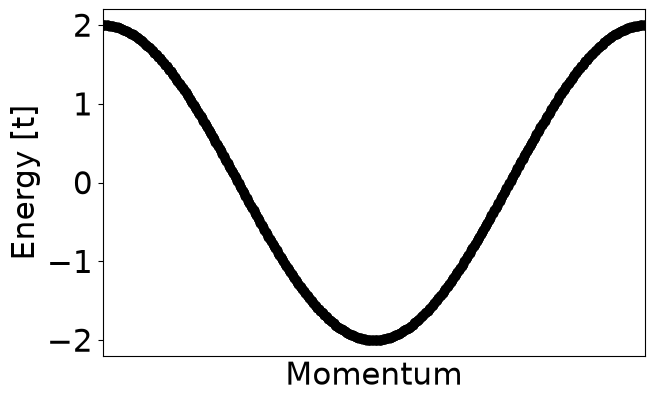

In [2]:
from pyqula import geometry
g = geometry.chain() # generate a chain
h = g.get_hamiltonian() # generate the Hamiltonian
(k,e) = h.get_bands() # compute band structure
plt.figure(figsize=(7,4.5))
plt.xlim([min(k),max(k)]) # adjust plot
plt.scatter(k,e,c="black") ; plt.xlabel("Momentum") ; plt.ylabel("Energy [t]") ; plt.xticks([]) # plot

### Quiz
- What is the functional form of the electronic dispersion?

## Finite size chains
We will now see how the spectra of a finite chain evolves with its length

Now instead of an infinite chain we take a finite chain with $L$ sites and open boundaries, which we build as a supercell of the chain with the periodicity removed, and we plot all its eigenvalues as a function of $L$. A finite system has a discrete spectrum, and here you see how that discrete spectrum fills the band of the infinite chain as $L$ grows. Look at the two eigenvalues closest to zero energy, and at how the distance between them, the finite size gap, changes as the chain becomes longer.

Text(0, 0.5, 'Energy [t]')

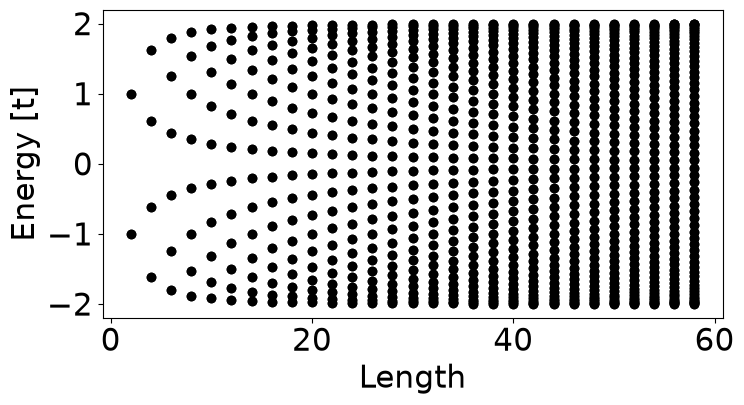

In [3]:
fig = plt.figure(figsize=(8,4))

Ls = range(2,60,2) # different lengths

for L in Ls:
    g = geometry.chain() # generate a chain
    g = g.get_supercell(L) # make a supercell
    g.dimensionality = 0 # make it finite
    h = g.get_hamiltonian() # generate the Hamiltonian
    (k,e) = h.get_bands() # compute band structure
    plt.scatter(e*0. + L,e,c="black")
plt.xlabel("Length") ; plt.ylabel("Energy [t]")

### Quiz
- Why does the number of eigenvalues increase with the system size?
- Make a log plot of the gap and obtain its functional dependence with the system size

## Density of states of a finite system as a function of the system size
We will now see how the size of a system influences its density of states

Here we compute for each finite chain the density of states $\rho(\omega) = -\frac{1}{\pi}\,\mathrm{Im}\,\mathrm{Tr}\,[\omega - H_0 + i0^+]^{-1}$, which counts how many eigenvalues there are at each energy $\omega$, with a small broadening that turns every level into a peak of finite width. The left panel shows the eigenvalues as before, and the right panel the density of states per site as a color map, with the length on the horizontal axis. Look at how the individual peaks evolve with $L$, and compare their separation with the width of the broadening.

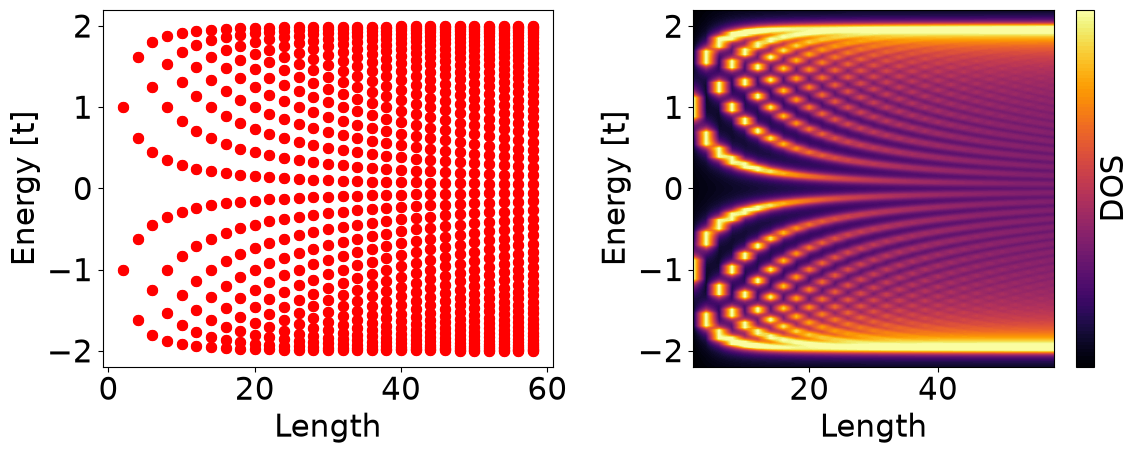

In [4]:
fig = plt.figure(figsize=(12,5))

Ls = range(2,60,2) # different lengths

ii = 0 # counter

edos = np.linspace(-2.2,2.2,300) # energies for the DOS
dos_array = [] # array for the DOS


plt.subplot(1,2,1)
    
for L in Ls:
    g = geometry.chain() # generate a chain
    g = g.get_supercell(L) # make a supercell
    g.dimensionality = 0 # make it finite
    h = g.get_hamiltonian() # generate the Hamiltonian
    (k,e) = h.get_bands() # compute band structure
    (ei,ddos) = h.get_dos(energies=edos)
    plt.scatter(e*0. + L,e,c="red",s=50)
    dos_array.append(ddos/L) # store

plt.xlabel("Length") ; plt.ylabel("Energy [t]")    

# plot the DOS
plt.subplot(1,2,2)
c = ii/len(Ls) # float for the color of the plot
dosz = np.array(dos_array).T ; vmax = 1.0 ; dosz[dosz>vmax] = vmax # saturate scale
plt.contourf(Ls,edos,dosz,levels=100,cmap="inferno") 
plt.colorbar(label="DOS",ticks=[],boundaries=[0,0.5,1])
plt.xlabel("Length") ; plt.ylabel("Energy [t]") 


plt.tight_layout()

### Quiz
- Make the system even bigger, what happens with the density of states?

## Magnetic order driven by interactions in a chain
We will now see how a Hubbard interaction gives rise to magnetic order in the chain at the mean-field level

Here we take the chain with two sites per unit cell, we add a Hubbard interaction $U=6t$, and we solve it at the mean-field level, meaning that the quartic term $U n_{i\uparrow} n_{i\downarrow}$ is replaced by an onsite exchange field set by the magnetization of each site, $H_{MF} = \sum_{ij\sigma} t_{ij}\, c_{i\sigma}^\dagger c_{j\sigma} - \frac{U}{2}\sum_i m_i \left(n_{i\uparrow} - n_{i\downarrow}\right)$ with $m_i = \langle n_{i\uparrow}\rangle - \langle n_{i\downarrow}\rangle$, solved self-consistently. We do this twice, starting from a ferromagnetic and from an antiferromagnetic guess, and for each one we plot the band structure and the magnetization on the sites. Compare the two band structures around zero energy.

(np.float64(-3.85),
 np.float64(3.85),
 np.float64(-0.05500000000000001),
 np.float64(0.05500000000000001))

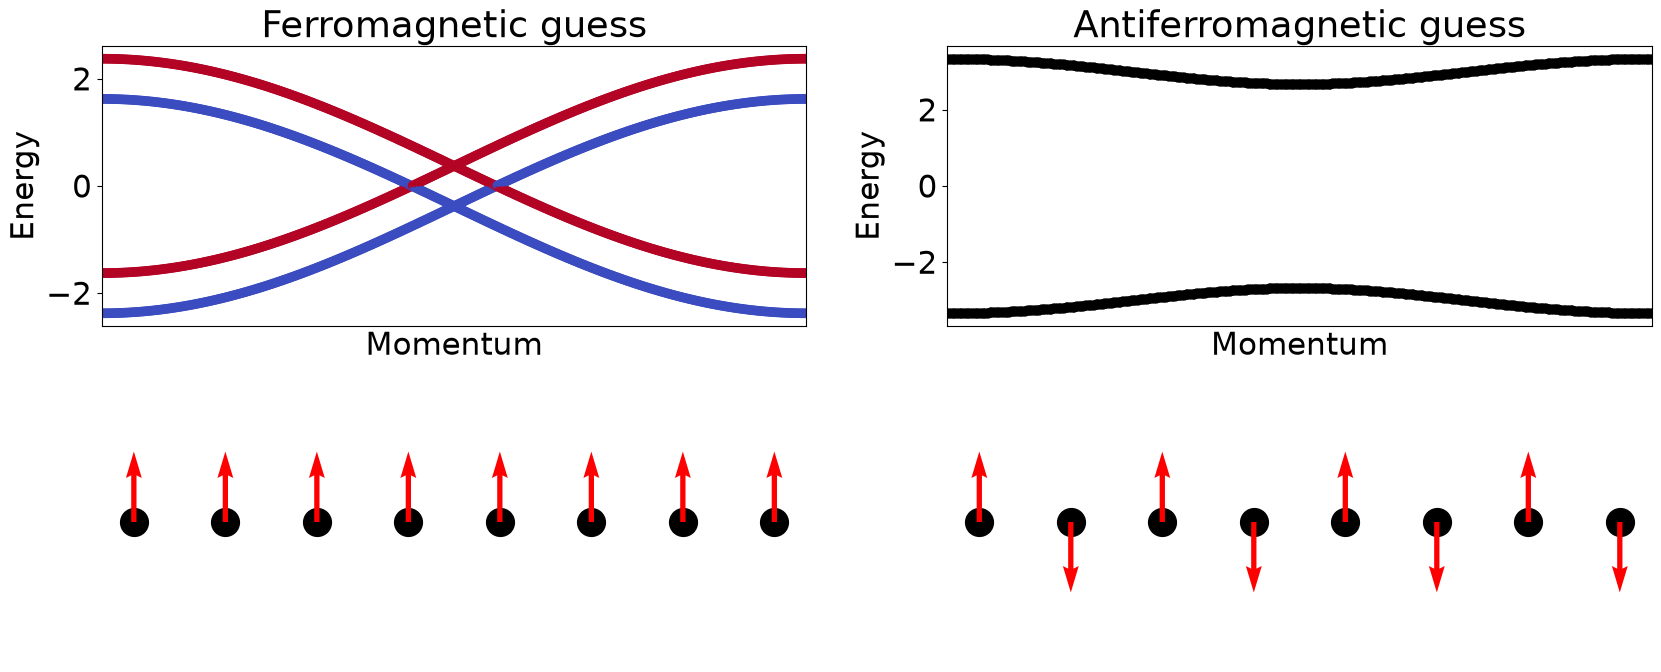

In [5]:
# let us now add interactions, and compute the electronic structure
from pyqula import geometry
g = geometry.bichain() # generate a chain with two sites per unit cell (with internal sublattice)
h = g.get_hamiltonian() # generate the Hamiltonian

U = 6.0 # value of the local interaction

# first with a ferromagnetic guess
plt.subplot(2,2,1)
plt.title("Ferromagnetic guess")
hfe = h.get_mean_field_hamiltonian(U=U,mf="ferro") # solve the interacting problem with a mean-field guess
(k,e,c) = hfe.get_bands(operator="sz") # compute band structure
plt.scatter(k,e,c=c) ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) 
plt.xlim([min(k),max(k)]) # plot

# plot magnetization
hs = hfe.get_supercell(4) ; gs = hs.geometry ; mz = hs.extract("mz") # supercell geometry and Mz
plt.subplot(2,2,3)
mz = hs.extract("mz") ; x = gs.r[:,0] ; y = gs.r[:,1] 
mz = mz/np.max(np.abs(mz)) # normalize
plt.scatter(x,y,c="black",s=400) ; plt.quiver(x,y,0.,mz,color="red",scale=10) ; plt.axis("off") # plot

# and with an antiferromagnetic guess
plt.subplot(2,2,2)
plt.title("Antiferromagnetic guess")
haf = h.get_mean_field_hamiltonian(U=U,mf="antiferro") # solve the interacting problem with a mean-field guess
(k,e) = haf.get_bands() # compute band structure
plt.scatter(k,e,c="black") ; plt.xlabel("Momentum") ; plt.ylabel("Energy") ; plt.xticks([]) 
plt.xlim([min(k),max(k)]) # plot

# plot magnetization
hs = haf.get_supercell(4) ; gs = hs.geometry ; mz = hs.extract("mz") # supercell geometry and Mz
plt.subplot(2,2,4)
mz = hs.extract("mz") ; x = gs.r[:,0] ; y = gs.r[:,1] 
mz = mz/np.max(np.abs(mz)) # normalize
plt.scatter(x,y,c="black",s=400) ; plt.quiver(x,y,0.,mz,color="red",scale=10) ; plt.axis("off") # plot

### Quiz
- Discuss which solution you think has the lowest energy, and why
- Compute the self-consistent solution for stronger values of the interaction. Which change do you observe?

## The spectra of a dimer
Here we will review the electronic spectra of a tight binding dimer

The dimer is the simplest case: two sites coupled by a hopping $t$, $H_0 = -t \sum_\sigma \left(c_{0\sigma}^\dagger c_{1\sigma} + c_{1\sigma}^\dagger c_{0\sigma}\right)$, and here we compute its eigenvalues with pyqula, plotting them one by one against the state index. This is the smallest system in which the interacting problem can be understood in full, so let us have its non-interacting spectrum in mind before we switch on $U$ in the next exercise. Count the eigenvalues, and look at which of them coincide.

Text(0.5, 0, 'State index')

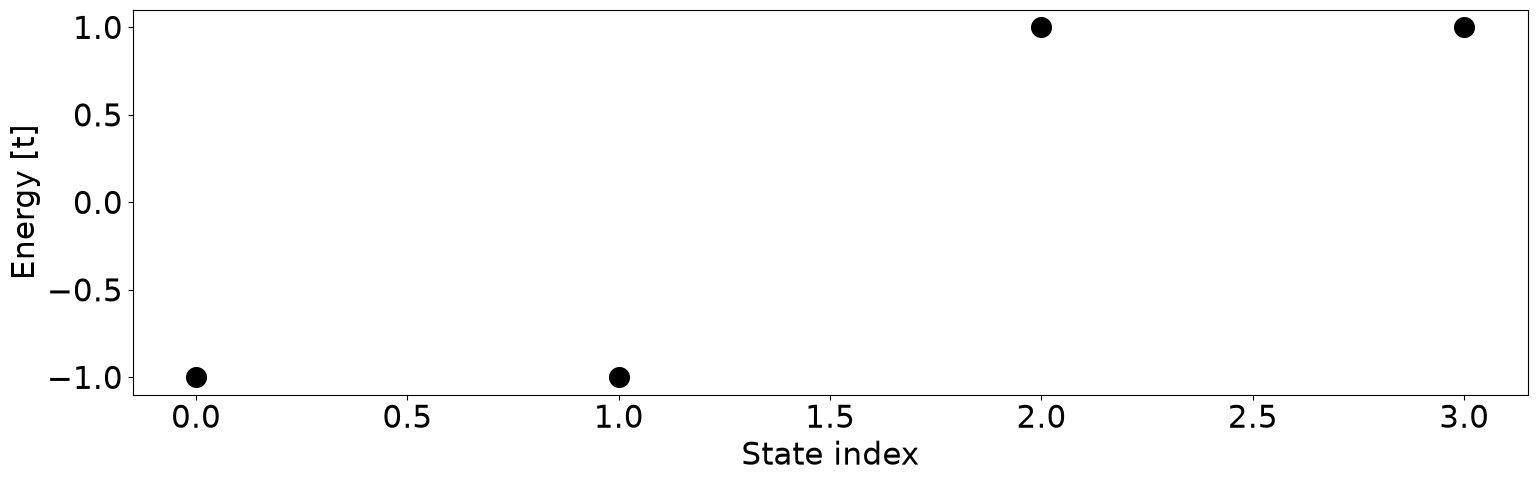

In [6]:
from pyqula import geometry
g = geometry.bichain() # generate a chain with two sites per unit cell (with internal sublattice)
g.dimensionality = 0 # just retain the two sites per unit cell

plt.figure(figsize=(18,5))
h = g.get_hamiltonian(has_spin=True) # generate Hamiltonian

(ks,es) = h.get_bands() # get bands
plt.scatter(range(len(es)),es,c="black",s=200) ; plt.ylabel("Energy [t]") ; plt.xlabel("State index")

### Quiz
- There are two sites in the system, why do we have four eigenstates?
- Why are the states degenerate in energy?

## The interacting Hubbard dimer
Here we will see how the magnetization evolves in an interacting dimer chain

Now we add the Hubbard interaction to the dimer, $H_{\mathrm{Hub}} = -t\sum_\sigma \left(c_{0\sigma}^\dagger c_{1\sigma} + \mathrm{h.c.}\right) + U\sum_i n_{i\uparrow} n_{i\downarrow}$, and we solve the mean-field problem for values of $U$ from $0$ to $10t$, starting each time from an antiferromagnetic guess. For every $U$ we store two numbers, the gap between the highest occupied and the lowest empty mean-field level, and the magnetization $\langle S_z\rangle$ of one of the two sites. Look at the shape of both curves, at where the magnetization starts being nonzero, and at what the gap is doing there.

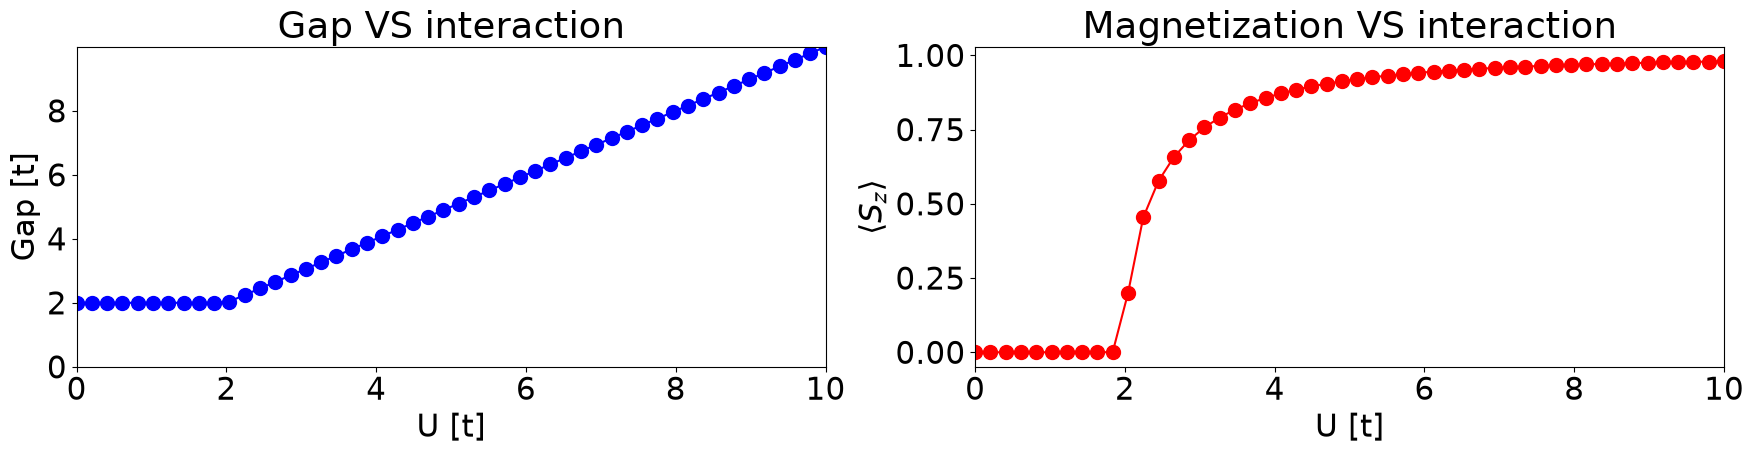

In [7]:
from pyqula import geometry
g = geometry.bichain() # generate a chain with two sites per unit cell (with internal sublattice)
L = 1 # size of the system
g = g.get_supercell(L) # make a supercell
g.dimensionality = 0 # just retain the two sites per unit cell
h0 = g.get_hamiltonian() # generate the Hamiltonian

Us = np.linspace(0.,10.,50) # values of the interaction U
mzs = [] # empty list for magnetizations
gaps = [] # gaps of the systems
for U in Us:
    h = h0.get_mean_field_hamiltonian(U=U,mf="antiferro",mix=0.9) # perform SCF
    mz = h.get_vev("mz")[1] # magnetization of the second site
    mzs.append(abs(mz)) # store the magnetization for that value of U
    gaps.append(h.get_gap()) # compute gap of the system and store it


plt.figure(figsize=(18,5))

plt.subplot(1,2,1) # plot the gap VS interaction
plt.title("Gap VS interaction")
plt.plot(Us,gaps,marker="o",c="blue",markersize=10) ; plt.xlim([min(Us),max(Us)])
plt.xlabel("U [t]") ; plt.ylabel("Gap [t]") ; plt.ylim([0,max(gaps)])

plt.subplot(1,2,2) # plot the magnetization VS interaction
plt.title("Magnetization VS interaction")
plt.plot(Us,mzs,marker="o",c="red",markersize=10) ; plt.xlim([min(Us),max(Us)])
plt.xlabel("U [t]") ; plt.ylabel("$\\langle S_z \\rangle $")
plt.tight_layout()

### Quiz
- Identify the non-interacting and strongly interacting limit in the plot
- Why does the magnetization saturate at large interactions?
- Why is there a critical value to have magnetization?
- Why is there a gap even when there is no magnetization?
- Make the system bigger. What happens, and why?

## Gap opening in the Hubbard model
We will now see how the Hubbard interaction gives rise to a gap opening in an interacting chain

Here we go back to the infinite chain with two sites per unit cell and we sweep the interaction from $U=0$ to $U=4t$, solving the mean-field problem at each step from an antiferromagnetic guess. The left panel shows the eigenvalues of the mean-field band structure as a function of $U$, and the right panel the density of states, one curve per value of $U$, shifted upwards as $U$ grows. Look at the energy window around zero, where the states of the metal were, and at how it evolves with $U$; at very large $U$ the gap grows as $\Delta \sim U$.

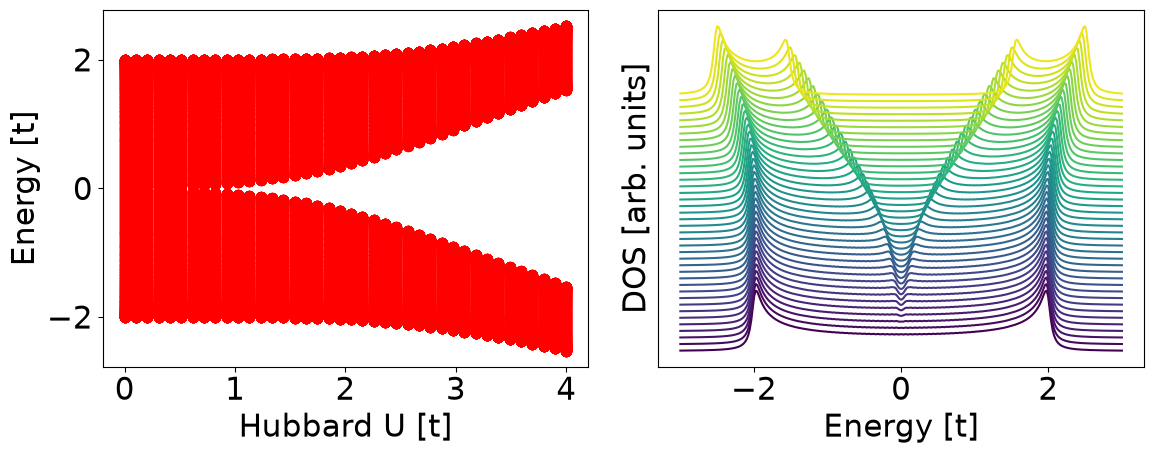

In [8]:
fig = plt.figure(figsize=(12,5))

Us = np.linspace(0.,4.0,40)

g = geometry.bichain() # generate a chain
h0 = g.get_hamiltonian() # generate the Hamiltonian
iU = 0 # counter
for U in Us:
    h = h0.get_mean_field_hamiltonian(U=U,mf="antiferro",mix=0.9) # perform SCF
#    h = h0.get_mean_field_hamiltonian(U=U,mf="ferro",mix=0.9) # perform SCF, with a ferromagnetic initialization
    (k,e) = h.get_bands() # compute band structure
    edos = np.linspace(-3,3.,300) # energies for the DOS
    (edos,ddos) = h.get_dos(energies=edos)
    plt.subplot(1,2,1)
    plt.scatter(e*0. + U,e,c="red",s=50)
    plt.subplot(1,2,2)
    c = iU/len(Us) # fraction of the U sweep completed, used to color the DOS curve
    plt.plot(edos,ddos+iU/4.,c=plt.cm.viridis(c))
    iU += 1
plt.subplot(1,2,1)
plt.xlabel("Hubbard U [t]") ; plt.ylabel("Energy [t]")

plt.subplot(1,2,2)
plt.xlabel("Energy [t]") ; plt.ylabel("DOS [arb. units]") ; plt.yticks([])

plt.tight_layout()

### Quiz
- Use a ferromagnetic initialization, what happens and why?

## Gap opening in a spinless interacting model
We will now see how in a spinless model, a gap opening appears in the presence of interactions

Now we take spinless fermions, so there is no Hubbard term to speak of, and the interaction is instead a repulsion between neighboring sites, $H_{\mathrm{CDW}} = -t\sum_i \left(c_i^\dagger c_{i+1} + \mathrm{h.c.}\right) + V \sum_i n_i n_{i+1}$. We solve it at the mean-field level at half filling for $V$ between $0$ and $3t$, and we plot the eigenvalues and the density of states as in the previous exercise. The variable `cdw` adds an external sublattice imbalance, an onsite energy of opposite sign on the two sites, and it is set to zero for now. Look at whether a gap opens, and compare with the spinful case above.

/u/40/ladovj1/data/Documents/programs/pyqula/src/pyqula/hamiltonians.py:978: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  h.intra = h.intra + h.spinless2full(sparse_diag([fermi],[0]))


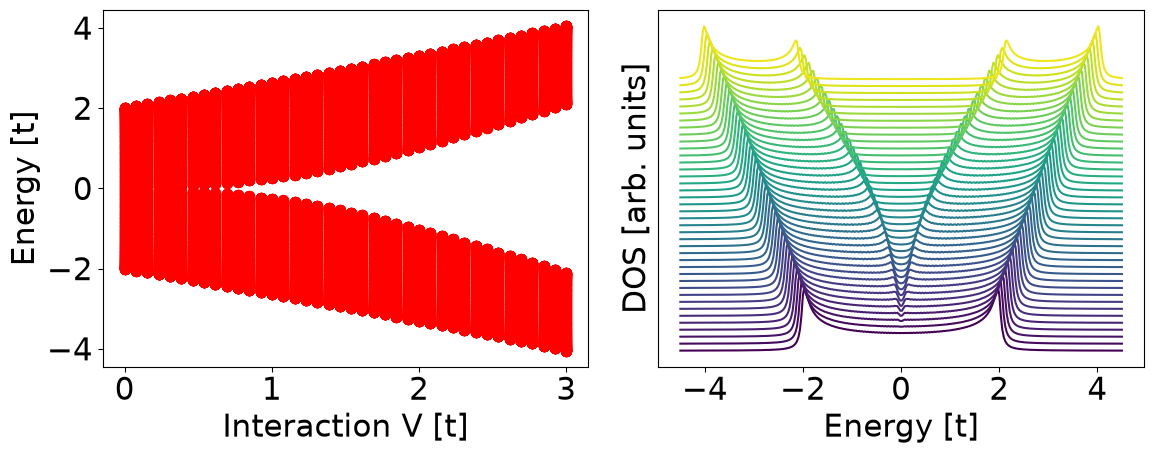

In [9]:
fig = plt.figure(figsize=(12,5))

Vs = np.linspace(0.,3.0,40)
g = geometry.bichain() # generate a chain with two sites
h0 = g.get_hamiltonian(has_spin=False) # generate the Hamiltonian
cdw = 0. # external CDW
h0.add_sublattice_imbalance(cdw) # add an external CDW

iV = 0

edos = np.linspace(-4.5,4.5,300) # energies for the DOS

for V in Vs:
    h = h0.get_mean_field_hamiltonian(V1=V,mf="CDW",mix=0.9,filling=0.5) # perform SCF
    (k,e) = h.get_bands() # compute band structure
    (edos,ddos) = h.get_dos(energies=edos)
    plt.subplot(1,2,1)
    plt.scatter(e*0. + V,e,c="red",s=50)
    plt.subplot(1,2,2)
    c = iV/len(Vs) # fraction of the V sweep completed, used to color the DOS curve
    plt.plot(edos,ddos+iV/8.,c=plt.cm.viridis(c))
    iV += 1
plt.subplot(1,2,1)
plt.xlabel("Interaction V [t]") ; plt.ylabel("Energy [t]")

plt.subplot(1,2,2)
plt.xlabel("Energy [t]") ; plt.ylabel("DOS [arb. units]") ; plt.yticks([])

plt.tight_layout()

### Quiz
- Why does the gap increase with the interaction strength?
- Add some charge density wave (cdw) externally to the system, what do you observe and why?

## Symmetry breaking in the spinless fermionic chain
We will now see how interactions create a charge imbalance in the interacting spinless model

For the same spinless chain, and for each value of $V$ from $0$ to $10t$, we compute the mean-field ground state and the occupation of the two sites of the unit cell, and we plot their difference $\delta n \equiv n_{\text{even}} - n_{\text{odd}}$. This is the order parameter of a charge density wave: it is zero when both sites are equally occupied, as in the metal, and nonzero when the electrons pile up on one sublattice. Look at where the curve leaves zero and at the value it reaches at large $V$.

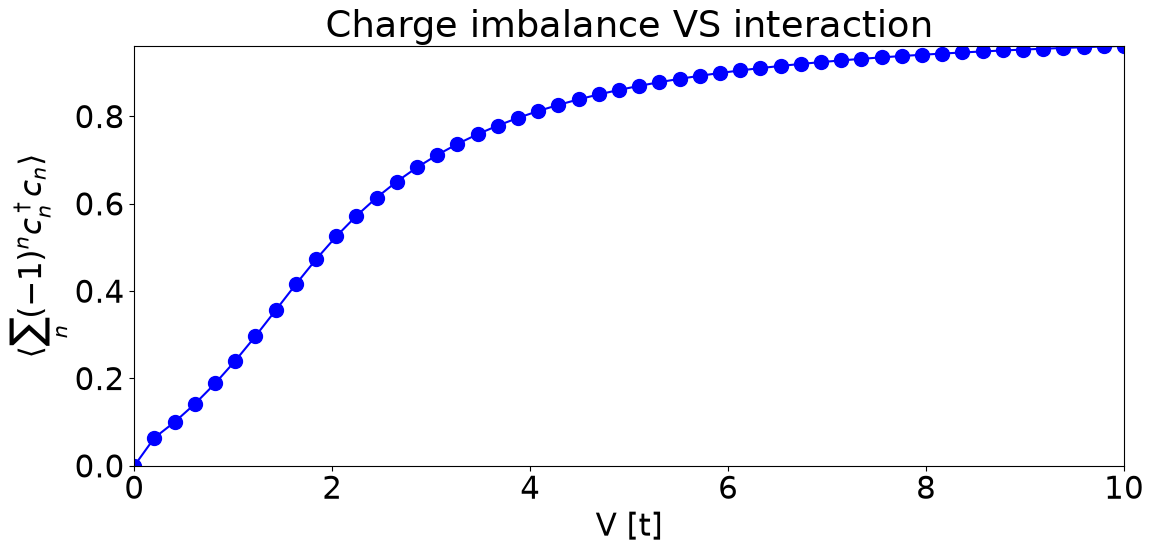

In [10]:
from pyqula import geometry
g = geometry.bichain() # generate a chain with two sites per unit cell (with internal sublattice)
h0 = g.get_hamiltonian(has_spin=False) # generate the Hamiltonian
cdw = 0. # external CDW
h0.add_sublattice_imbalance(cdw) # add an external CDW


Vs = np.linspace(0.,10.,50) # values of the interaction V
dens = [] # empty list for charge imbalances
for V in Vs:
    h = h0.get_mean_field_hamiltonian(V1=V,mf="CDW",mix=0.5,filling=0.5) # perform SCF
    den = h.get_vev(operator=None) # site occupations (charge densities)
    dens.append(abs(den[0]-den[1])) # store the charge imbalance for that value of V

    
plt.figure(figsize=(12,6))

plt.title("Charge imbalance VS interaction")
plt.plot(Vs,dens,marker="o",c="blue",markersize=10) ; plt.xlim([min(Vs),max(Vs)])
plt.xlabel("V [t]") ; plt.ylabel("$\\langle \\sum_n (-1)^n c^\\dagger_n c_n \\rangle $") ; plt.ylim([0,max(dens)])
plt.tight_layout()


### Quiz
- Why does the charge imbalance saturate to 1 for large interactions?
- Add some CDW externally to the system, what do you observe and why?

## The strongly interacting limit of the Hubbard model
Let us now compare the energies of a ferromagnetic and antiferromagnetic state in the strong coupling limit

Here we solve the mean-field Hubbard chain twice for each $U$, once converging to the ferromagnetic solution and once to the antiferromagnetic one, and we plot the difference between their total energies, $E_{\mathrm{FM}} - E_{\mathrm{AFM}}$, for $U$ between $20t$ and $60t$. This is the regime where the interaction is much larger than the hopping, so every site holds one electron and the only question left is how the moments on neighboring sites orient with respect to each other. Look at the sign of the curve and at how fast it approaches zero.

Text(0, 0.5, 'Energy FE - AF [t]')

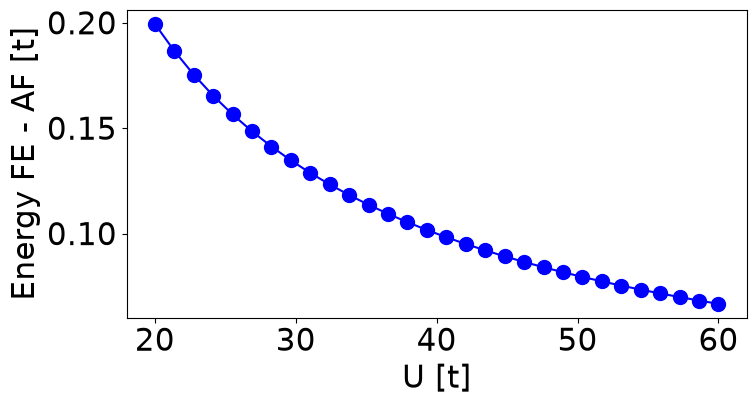

In [11]:
# let us now compute the energy difference as a function of U
from pyqula import geometry

fig = plt.figure(figsize=(8,4))

def get_energy_difference(U):
    g = geometry.bichain() # generate a chain with two sites per unit cell
    h = g.get_hamiltonian() # generate the Hamiltonian
    (hfe,efe) = h.get_mean_field_hamiltonian(U=U,return_total_energy=True,mf="ferro",mix=0.9) # FE
    (haf,eaf) = h.get_mean_field_hamiltonian(U=U,return_total_energy=True,mf="antiferro",mix=0.9) # AF
    return efe - eaf

Us = np.linspace(20.,60,30) # values of U considered

Et = [get_energy_difference(U) for U in Us] # energy differences

plt.plot(Us,Et,c="blue",marker="o",markersize=10) # plot total energy VS value of U
plt.xlabel("U [t]") ; plt.ylabel("Energy FE - AF [t]")

### Quiz
- Which state has the lowest energy?
- Discuss why the dependence of 1/U is observed in the energy differences between FE and AF configurations
- Compute this very same curve but going to lower values of U. Why does the 1/U behavior break down?

## Non-collinear magnetism in the Hubbard model from competing interactions
Let us now include further neighbor hoppings, which promotes competing magnetic interactions

Remember from the lecture that at large $U$ the Hubbard model behaves as a Heisenberg model, $H_{\mathrm{Heis}} = \sum_{ij} J_{ij}\, \mathbf{S}_i \cdot \mathbf{S}_j$ with $J_{ij} \sim t_{ij}^2/U$, so every hopping we include gives rise to an exchange coupling of its own. Here we take a finite chain of 20 sites with a first-neighbor hopping $t_1 = t$ and a second-neighbor hopping $t_2 = 0.3t$, a strong interaction $U=10t$, and we let the mean-field magnetization point anywhere in the $xy$ plane, plotting the resulting moment on each site as an arrow. Look at the angle between neighboring arrows along the chain.

(np.float64(-10.45),
 np.float64(10.45),
 np.float64(-0.05500000000000001),
 np.float64(0.05500000000000001))

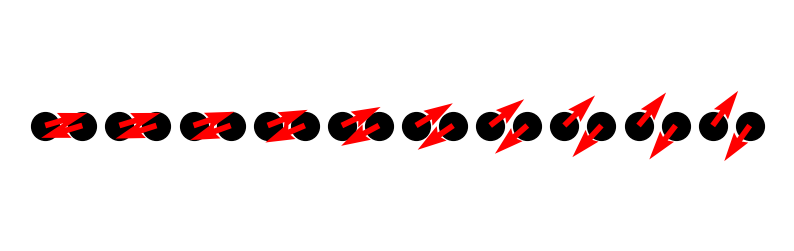

In [12]:
from pyqula import geometry
g = geometry.chain() # generate a chain 
g = g.get_supercell(20) ; g.dimensionality = 0 # use open boundaries, to avoid incommensurability issues
h = g.get_hamiltonian(tij=[1.,.3]) # generate the Hamiltonian

# generate the selfconsistent (SCF) Hamiltonian
U = 10. # strong Hubbard interaction
h = h.get_mean_field_hamiltonian(U=U,mf="XY",mix=0.9) # solve the interacting problem with a mean-field guess
mx = h.extract("mx") ; my = h.extract("my") ; x = h.geometry.r[:,0] ; y = h.geometry.r[:,1] # get magnetization
plt.figure(figsize=(10,3))
plt.scatter(x,y,c="black",s=400) ; plt.quiver(x,y,mx,my,color="red") ; plt.axis("equal") ; plt.axis("off") # plot magnetization, equal aspect so spin angles are shown undistorted

### Exercise
- Discuss why including second neighbor hopping gives rise to a non-collinear magnetic state
- Is there a longer-neighbor hopping that can be included that does not lead to non-collinearity? Include it and show that you recover the antiferromagnetic state

## Non-collinear magnetic order from geometric frustration
We will now address 2D models that show non-collinear magnetism due to the geometric frustration of the lattice.

Now we move to two dimensions and we take a triangular lattice with first-neighbor hopping, a $3\times3$ supercell so that the magnetic order can have a larger unit cell than the lattice, and again $U=10t$ with the moments free to rotate in the $xy$ plane. On a triangular lattice three neighboring sites form a triangle, and there is no way of making all three pairs antiparallel at the same time, which is what is called geometric frustration. The plot shows the moments on a repeated supercell; look at the angle between the arrows on the three sites of a triangle.

(np.float64(-4.124999999999999),
 np.float64(4.124999999999999),
 np.float64(-2.3815698604072066),
 np.float64(2.381569860407206))

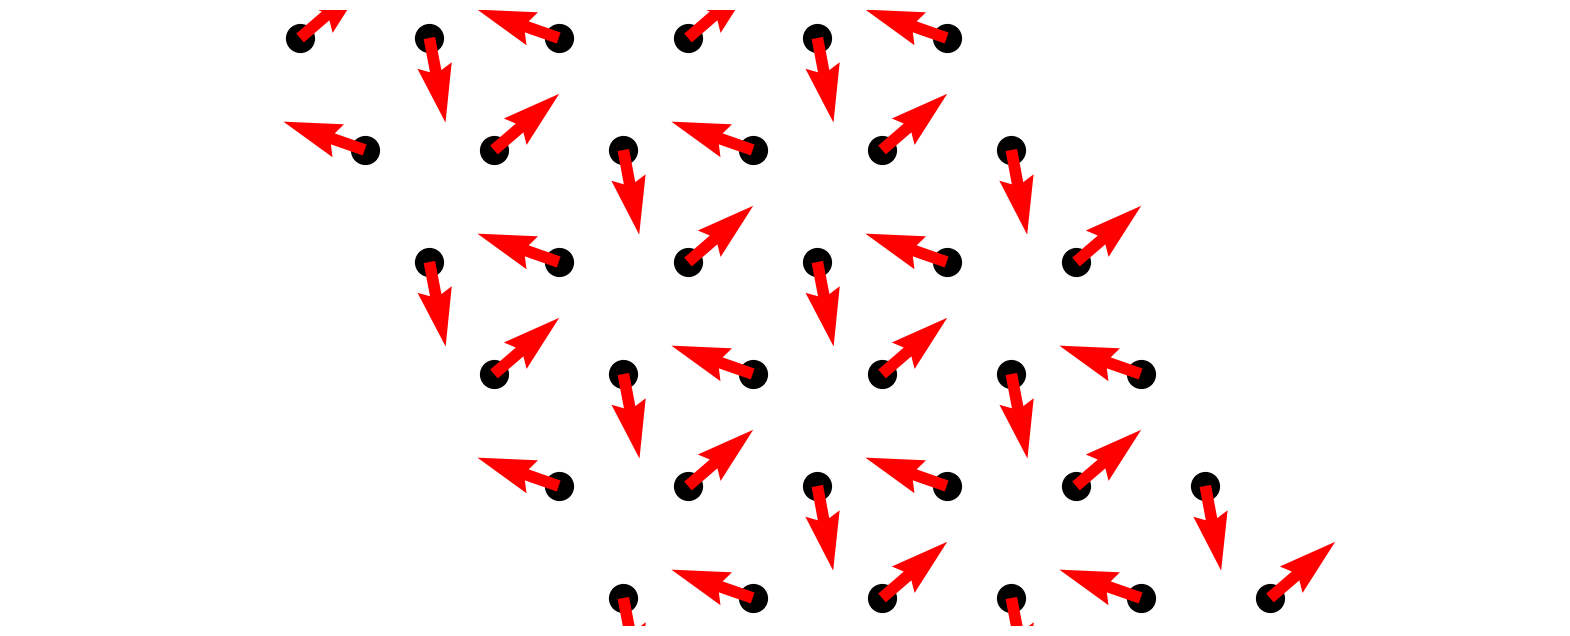

In [13]:
from pyqula import geometry
g = geometry.triangular_lattice() # generate a triangular lattice
g = g.get_supercell((3,3)) # make a supercell
h = g.get_hamiltonian() # generate the Hamiltonian

# generate the SCF Hamiltonian
U = 10. # strong Hubbard interaction
h = h.get_mean_field_hamiltonian(U=U,mf="XY",mix=0.9) # solve the interacting problem with a mean-field guess
hs = h.get_supercell(2) # generate a supercell
mx = hs.extract("mx") ; my = hs.extract("my") ; x = hs.geometry.r[:,0] ; y = hs.geometry.r[:,1] # get magnetization
plt.scatter(x,y,c="black",s=400) ; plt.quiver(x,y,mx,my,color="red")  # plot magnetization
plt.axis("equal") ; plt.axis("off")

### Quiz
- Plot the band structure for the SCF solution for the 3x3 supercell, and estimate its gap
- Plot the band structure for the SCF solution for the 1x1 supercell, and estimate its gap
- Can you infer which one is the lowest energy solution, and why?